---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** __안지혜__ &nbsp; **학번:** __20251287__ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [34]:
import pandas as pd

# 데이터 파일 로드 
df = pd.read_excel('acute_inhalation.xlsx', sheet_name='Data') 

# 1. 데이터셋의 크기 확인 (행, 열)
print("데이터셋 크기:", df.shape)
print("-" * 50)

# 2. 어떤 컬럼들이 있는지 확인
print("컬럼 목록:")
print(df.columns.tolist())
print("-" * 50)

# 3. 데이터 상위 5행 출력해서 눈으로 확인
df.head()

데이터셋 크기: (5505, 23)
--------------------------------------------------
컬럼 목록:
['Record_ID', 'Data_Type', 'Internal_Data_Source', 'Formulation_ID', 'Formulation_Name', 'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient', 'Mixture', 'Assay', 'Duration', 'Endpoint', 'Response_Modifier', 'Response', 'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name', 'Synonyms', 'URL_CompTox', 'URL_CEBS']
--------------------------------------------------


,Record_ID,Data_Type,Internal_Data_Source,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,...,Response_Modifier,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,acute_inhalation_438,In Vivo,AcuteInhal6pack,MIX514,Vapona Concentrate Insecticide,Dichlorvos-related compounds,NaN,NaN,3.00,Mixture,...,NaN,3,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,acute_inhalation_307,In Vivo,AcuteInhal6pack,MIX382,Ravap EC,Dichlorvos-related compounds,NaN,NaN,0.40,Mixture,...,NaN,4,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,acute_inhalation_478,In Vivo,AcuteInhal6pack,MIX82,Captan 4L,Captan-related derivatives,NaN,NaN,0.97,Mixture,...,NaN,4,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,acute_inhalation_476,In Vivo,AcuteInhal6pack,MIX78,Callisto Xtra,Atrazine-related compounds,NaN,NaN,0.70,Mixture,...,NaN,4,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,acute_inhalation_438,In Vivo,AcuteInhal6pack,MIX514,Vapona Concentrate Insecticide,Dichlorvos-related compounds,NaN,NaN,3.00,Mixture,...,NaN,3,Unitless,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df['Endpoint'].value_counts()

Endpoint
LC50                  3932
EPA Classification     789
GHS Classification     784
Name: count, dtype: int64

In [36]:
# 세이브해둔 정제 데이터 불러오기
df_smi = pd.read_csv('skin.csv')

In [37]:
import pandas as pd

# 1. 업로드한 원본 엑셀 파일의 'Data' 시트를 읽어옵니다.
excel_file = 'acute_inhalation.xlsx'
df_excel = pd.read_excel(excel_file, sheet_name='Data')

# 2. 머신러닝 파이프라인에서 가장 가볍고 빠르게 읽을 수 있는 .csv 파일로 저장합니다.
# 인코딩은 한글과 특수문자가 깨지지 않는 글로벌 표준 'utf-8'로 지정합니다.
csv_file_name = 'acute_inhalation_data.csv'
df_excel.to_csv(csv_file_name, index=False, encoding='utf-8')

print("=" * 50)
print(f"🎉 CSV 변환 및 저장 완료!")
print(f"-> 생성된 파일명: {csv_file_name}")
print("=" * 50)

🎉 CSV 변환 및 저장 완료!
-> 생성된 파일명: acute_inhalation_data.csv


In [38]:
print("=" * 60)
print("🔍 수업 초반 실습 기반: 중복 화합물 체크 및 정제")
print("=" * 60)

# 1. 중복된 SMILES 코드가 몇 개나 있는지 확인 (수업 내용 반영)
# 'Structure: SMILES' 또는 'SMILES' 컬럼 기준
smiles_col = 'Structure: SMILES' if 'Structure: SMILES' in df_clean.columns else 'SMILES'

duplicate_count = df_clean.duplicated(subset=[smiles_col]).sum()
print(f"   - 데이터셋 내 중복된 SMILES 구조식 개수: {duplicate_count}개")

# 2. 중복 데이터 제거 (첫 번째 데이터만 남기고 제거)
df_unique = df_clean.drop_duplicates(subset=[smiles_col], keep='first').copy()

print(f"   - 중복 제거 후 최종 유일 화합물 개수: {df_unique.shape[0]}개")
print("=" * 60)

# 이후 단계에서 쓸 수 있도록 데이터프레임 이름 매핑
df_filtered = df_unique.copy()

🔍 수업 초반 실습 기반: 중복 화합물 체크 및 정제
   - 데이터셋 내 중복된 SMILES 구조식 개수: 3584개
   - 중복 제거 후 최종 유일 화합물 개수: 1689개


In [39]:
#2단계
import pandas as pd
import numpy as np

# 1. 앞 단계에서 성공적으로 저장한 CSV 파일 불러오기
df_raw = pd.read_csv('acute_inhalation_data.csv', encoding='utf-8')

print("=" * 60)
print(f"1. 원본 데이터셋 로드 완료")
print(f"   - 전체 레코드(행) 수: {df_raw.shape[0]}개")
print(f"   - 전체 컬럼(열) 수: {df_raw.shape[1]}개")
print("=" * 60)

# 2. 머신러닝(RDKit)의 핵심 입력값인 SMILES 구조식이 없는 행 제거
# NTP ICE 데이터셋의 규격에 맞춰 컬럼명을 자동 매핑합니다.
smiles_col = 'Structure: SMILES' if 'Structure: SMILES' in df_raw.columns else 'SMILES'

# 결측치 제거 수행
df_clean = df_raw.dropna(subset=[smiles_col]).copy()

print(f"2. SMILES 결측치 처리 결과")
print(f"   - 제거된 결측치 수: {df_raw.shape[0] - df_clean.shape[0]}개")
print(f"   - 남은 유효 데이터 수: {df_clean.shape[0]}개")
print("=" * 60)

# 데이터가 잘 들어왔는지 상위 3개만 가볍게 확인
df_clean[[smiles_col]].head(3)

1. 원본 데이터셋 로드 완료
   - 전체 레코드(행) 수: 5505개
   - 전체 컬럼(열) 수: 23개
2. SMILES 결측치 처리 결과
   - 제거된 결측치 수: 232개
   - 남은 유효 데이터 수: 5273개


,SMILES
14,ClCC=C(Cl)CCl
15,COC(C)C=CC
16,CCCCN(C1CC(C)(C)NC(C)(C)C1)C1=NC(=NC(NCCCN(CCN...


In [52]:
import pandas as pd
import numpy as np

# 1. 원본 CSV 파일 불러오기
df_raw = pd.read_csv('acute_inhalation_data.csv', encoding='utf-8')

print("=" * 60)
print(f"1. 원본 데이터셋 로드 완료")
print(f"   - 전체 레코드(행) 수: {df_raw.shape[0]}개")
print(f"   - 전체 컬럼(열) 수: {df_raw.shape[1]}개")
print("=" * 60)

# 2. SMILES 결측치 제거
smiles_col = 'Structure: SMILES' if 'Structure: SMILES' in df_raw.columns else 'SMILES'
df_clean = df_raw.dropna(subset=[smiles_col]).copy()

print(f"2. SMILES 결측치 처리 결과")
print(f"   - 제거된 결측치 수: {df_raw.shape[0] - df_clean.shape[0]}개")
print(f"   - 남은 유효 데이터 수: {df_clean.shape[0]}개")
print("=" * 60)

1. 원본 데이터셋 로드 완료
   - 전체 레코드(행) 수: 5505개
   - 전체 컬럼(열) 수: 23개
2. SMILES 결측치 처리 결과
   - 제거된 결측치 수: 232개
   - 남은 유효 데이터 수: 5273개


In [53]:
print("=" * 60)
print("🔍 수업 초반 실습 기반: 중복 화합물 체크 및 정제")
print("=" * 60)

# 1. 중복된 SMILES 구조식 확인
smiles_col = 'Structure: SMILES' if 'Structure: SMILES' in df_clean.columns else 'SMILES'
duplicate_count = df_clean.duplicated(subset=[smiles_col]).sum()
print(f"   - 데이터셋 내 중복된 SMILES 구조식 개수: {duplicate_count}개")

# 2. 중복 제거 수행 (첫 번째 데이터만 남기기)
# 다음 셀로 데이터를 깨끗하게 넘겨주기 위해 변수명을 df_filtered로 통일합니다.
df_filtered = df_clean.drop_duplicates(subset=[smiles_col], keep='first').copy()

print(f"   - 중복 제거 후 최종 유일 화합물 개수: {df_filtered.shape[0]}개")
print("=" * 60)

🔍 수업 초반 실습 기반: 중복 화합물 체크 및 정제
   - 데이터셋 내 중복된 SMILES 구조식 개수: 3584개
   - 중복 제거 후 최종 유일 화합물 개수: 1689개


In [56]:
#수정된 2단계
# 이제 앞 셀에서 중복이 완벽히 제거된 df_filtered(1,689개)를 이어받아 라벨링을 진행합니다!
def advanced_label_inhalation(row):
    endpoint_val = str(row['Endpoint']).lower() if 'Endpoint' in row else ''
    response_val = str(row['Response']).lower() if 'Response' in row else ''
    
    # 기준 A: GHS/EPA 등급이 1, 2, 3인 경우 (강한 독성)
    if 'classification' in endpoint_val:
        if response_val in ['1', '2', '3', '1.0', '2.0', '3.0']:
            return 1
        elif response_val in ['4', '5', '4.0', '5.0', 'nc', 'not classified']:
            return 0
            
    # 기준 B: LC50 수치 기준 (5.0 mg/L 이하면 독성)
    if 'lc50' in endpoint_val:
        try:
            res_float = float(row['Response'])
            if res_float <= 5.0:
                return 1
            else:
                return 0
        except:
            pass

    if 'toxic' in response_val or 'active' in response_val:
        return 1
        
    return 0

# 중복 제거된 데이터에 라벨링 알고리즘 적용
df_filtered['Label'] = df_filtered.apply(advanced_label_inhalation, axis=1)

# 최종 정제된 데이터프레임 빌드
df_final = df_filtered.dropna(subset=['Label']).copy()
df_final['Label'] = df_final['Label'].astype(int)

print("=" * 60)
print("📊 [업데이트 완료] 중복 제거 반영된 최종 라벨 분포 (0: 비독성 / 1: 독성)")
print(df_final['Label'].value_counts())
print("-" * 60)

# 기말고사 양식 출력 규격 맞춤 저장
df_final.to_csv('final_dataset_descriptors.csv', index=False, encoding='utf-8')
print("🎉 중복 없는 진짜 데이터가 'final_dataset_descriptors.csv'로 최종 저장되었습니다!")
print("=" * 60)

📊 [업데이트 완료] 중복 제거 반영된 최종 라벨 분포 (0: 비독성 / 1: 독성)
Label
1    998
0    691
Name: count, dtype: int64
------------------------------------------------------------
🎉 중복 없는 진짜 데이터가 'final_dataset_descriptors.csv'로 최종 저장되었습니다!


In [57]:
# 1. 혼합물(Mixture)을 제외하고, 분자 구조가 명확한 순수 화합물 위주로 필터링
# NTP ICE의 'Chemical: Form' 또는 'Form' 컬럼을 활용합니다.
form_col = 'Chemical: Form' if 'Chemical: Form' in df_clean.columns else 'Form'

if form_col in df_clean.columns:
    # 'mixture'(혼합물)나 'unknown'(알 수 없음) 문자열이 들어간 행을 제거합니다.
    df_filtered = df_clean[~df_clean[form_col].str.contains('mixture|unknown', case=False, na=False)].copy()
    print(f"-> 혼합물/노이즈 제거 후 데이터 수: {df_filtered.shape[0]}개")
else:
    df_filtered = df_clean.copy()
    print("-> 'Chemical: Form' 컬럼이 없어 다음 필터링으로 넘어갑니다.")

# 2. 실험 동물 종(Species) 필터링
# 독성 실험의 데이터 일관성을 위해 주로 사용되는 'Rat'(쥐)이나 'Mouse' 데이터 위주로 선별합니다.
if 'Species' in df_filtered.columns:
    df_filtered = df_filtered[df_filtered['Species'].str.contains('rat|mouse|human', case=False, na=False)].copy()
    print(f"-> 주요 실험 종(Rat/Mouse/Human) 필터링 후 최종 데이터 수: {df_filtered.shape[0]}개")

print("=" * 60)
print(f"🧼 2단계 필터링 완료: 최종 데이터 {df_filtered.shape[0]}개 확보")
print("=" * 60)

-> 'Chemical: Form' 컬럼이 없어 다음 필터링으로 넘어갑니다.
🧼 2단계 필터링 완료: 최종 데이터 5273개 확보


In [62]:
# 아까 중복 제거를 통해 만들어진 df_filtered(1,689개) 데이터를 완벽하게 이어받습니다.
df_step2 = df_filtered.copy()

print("=" * 60)
print("🧼 2단계: 혼합물 및 실험 종(Species) 추가 정제 시작")
print("=" * 60)

# 1. 혼합물(Mixture) 제외 필터링
form_col = 'Chemical: Form' if 'Chemical: Form' in df_step2.columns else 'Form'

if form_col in df_step2.columns:
    df_step2 = df_step2[~df_step2[form_col].str.contains('mixture|unknown', case=False, na=False)].copy()
    print(f"   - 혼합물/노이즈 제거 후 데이터 수: {df_step2.shape[0]}개")
else:
    print("   - [안내] 'Chemical: Form' 컬럼이 없어 혼합물 필터링을 패스합니다.")

# 2. 실험 동물 종(Species) 필터링 (Rat, Mouse, Human 위주로 일관성 확보)
species_col = 'Species' if 'Species' in df_step2.columns else None

if species_col and species_col in df_step2.columns:
    # 데이터가 꼬이는 것을 방지하기 위해 'rat|mouse|human'만 선별
    df_step2 = df_step2[df_step2[species_col].str.contains('rat|mouse|human', case=False, na=False)].copy()
    print(f"   - 주요 실험 종(Rat/Mouse/Human) 필터링 후 데이터 수: {df_step2.shape[0]}개")
else:
    print("   - [안내] 'Species' 컬럼이 데이터셋에 존재하지 않아 필터링을 패스합니다.")

# 3. 최종 데이터를 다음 라벨링 단계(df_filtered)로 다시 안전하게 토스합니다.
df_filtered = df_step2.copy()

print("-" * 60)
print(f"✨ 2단계 추가 필터링 최종 완료: 유효 데이터 {df_filtered.shape[0]}개 확보")
print("=" * 60)

🧼 2단계: 혼합물 및 실험 종(Species) 추가 정제 시작
   - [안내] 'Chemical: Form' 컬럼이 없어 혼합물 필터링을 패스합니다.
   - [안내] 'Species' 컬럼이 데이터셋에 존재하지 않아 필터링을 패스합니다.
------------------------------------------------------------
✨ 2단계 추가 필터링 최종 완료: 유효 데이터 5273개 확보


In [58]:
import numpy as np

# 1. NTP ICE 흡입 독성의 핵심 결과 컬럼명 찾기
# 데이터셋에 따라 'Inhalation Toxicity Classification' 또는 'Endpoint' 등의 이름을 가집니다.
target_col = None
possible_cols = ['Inhalation Toxicity Classification', 'Endpoint', 'Classification', 'Effect']

for col in possible_cols:
    if col in df_filtered.columns:
        target_col = col
        break

if target_col is None:
    # 만약 위 목록에 없다면 데이터셋에 존재하는 다른 적절한 컬럼을 찾기 위해 첫 번째 컬럼을 임시 지정합니다.
    target_col = df_filtered.columns[0]

print(f"🎯 라벨링에 사용할 타깃 컬럼: '{target_col}'")

# 2. 이진 분류(0과 1)를 위한 라벨링 함수 정의
# 독성이 강한 등급(Category 1, 2, 3 또는 Toxic/Active)은 1, 나머지는 0으로 변환합니다.
def label_toxicity(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower()
    
    # 독성 유발 및 강한 독성 카테고리 키워드 기준
    if 'toxic' in value or 'category 1' in value or 'category 2' in value or 'category 3' in value or 'active' in value:
        return 1
    else:
        return 0

# 라벨링 적용
df_filtered['Label'] = df_filtered[target_col].apply(label_toxicity)

# 라벨에 결측치가 생겼다면 제거
df_final = df_filtered.dropna(subset=['Label']).copy()
df_final['Label'] = df_final['Label'].astype(int)

print("-" * 60)
print("📊 라벨 분포 결과 (0: 비독성 / 1: 독성)")
print(df_final['Label'].value_counts())
print("-" * 60)

# 3. ✨ 유저님이 말씀하셨던 "중간 세이브" 코드 적용!
# 정제가 완벽히 끝난 최종 데이터프레임을 'inhalation_clean.csv'로 백업합니다.
df_final.to_csv('inhalation_clean.csv', index=False, encoding='utf-8')
print("🎉 정제 완료된 데이터가 'inhalation_clean.csv'로 안전하게 중간 저장되었습니다!")
print("=" * 60)

🎯 라벨링에 사용할 타깃 컬럼: 'Endpoint'
------------------------------------------------------------
📊 라벨 분포 결과 (0: 비독성 / 1: 독성)
Label
0    5273
Name: count, dtype: int64
------------------------------------------------------------
🎉 정제 완료된 데이터가 'inhalation_clean.csv'로 안전하게 중간 저장되었습니다!


In [59]:
import numpy as np

# 1. NTP ICE 급성 흡입 독성의 GHS/EPA 등급이나 반응값(Response)을 기준으로 정밀 라벨링합니다.
# 안전한 분류를 위해 'Response'(실험 수치)와 'Endpoint'를 함께 분석합니다.

def advanced_label_inhalation(row):
    # 컬럼 존재 여부 확인 후 값 추출
    endpoint_val = str(row['Endpoint']).lower() if 'Endpoint' in row else ''
    response_val = str(row['Response']).lower() if 'Response' in row else ''
    
    # 기준 A: GHS Classification 또는 EPA Classification 등급이 1, 2, 3인 경우 (강한 독성)
    # GHS/EPA 등급에서 1~3등급은 대개 흡입 시 치명적이거나 위험한 독성 물질입니다.
    if 'classification' in endpoint_val:
        if response_val in ['1', '2', '3', '1.0', '2.0', '3.0']:
            return 1  # 독성 있음
        elif response_val in ['4', '5', '4.0', '5.0', 'nc', 'not classified']:
            return 0  # 독성 없음/낮음
            
    # 기준 B: 만약 LC50 수치 데이터가 직접 들어가 있고 결과가 기재된 경우
    # 수치형 데이터가 있을 때 특정 임계값(예: 5.0 mg/L 이하)을 독성으로 잡는 로직
    if 'lc50' in endpoint_val:
        try:
            res_float = float(row['Response'])
            if res_float <= 5.0: # 4시간 노출 기준 대략적인 독성 임계치
                return 1
            else:
                return 0
        except:
            pass

    # 기본값은 비독성(0)으로 처리하되 키워드 검증 추가
    if 'toxic' in response_val or 'active' in response_val:
        return 1
        
    return 0

# 고급 라벨링 알고리즘 적용
df_filtered['Label'] = df_filtered.apply(advanced_label_inhalation, axis=1)

# 라벨 최종 정제 및 확인
df_final = df_filtered.dropna(subset=['Label']).copy()
df_final['Label'] = df_final['Label'].astype(int)

print("=" * 60)
print("📊 [수정 완료] 흡입 독성 라벨 분포 결과 (0: 비독성 / 1: 독성)")
print(df_final['Label'].value_counts())
if len(df_final['Label'].unique()) < 2:
    print("⚠️ 경고: 여전히 하나의 라벨만 존재합니다. 이 경우 'Response' 컬럼 고유값을 확인해야 합니다.")
print("-" * 60)

# 중간 세이브 파일 교체 저장
df_final.to_csv('inhalation_clean.csv', index=False, encoding='utf-8')
print("🎉 실제 독성학 기준이 반영된 데이터가 'inhalation_clean.csv'로 업데이트 저장되었습니다!")
print("=" * 60)

📊 [수정 완료] 흡입 독성 라벨 분포 결과 (0: 비독성 / 1: 독성)
Label
0    2646
1    2627
Name: count, dtype: int64
------------------------------------------------------------
🎉 실제 독성학 기준이 반영된 데이터가 'inhalation_clean.csv'로 업데이트 저장되었습니다!


In [60]:
import warnings
from rdkit import RDLogger

# 1. 파이썬 기본 라이브러리(Matplotlib 등)의 경고 메시지 끄기
warnings.filterwarnings(action='ignore')

# 2. RDKit 내부의 자질구레한 로그/경고 메시지(Explicit valence 등) 끄기
RDLogger.DisableLog('rdApp.*')

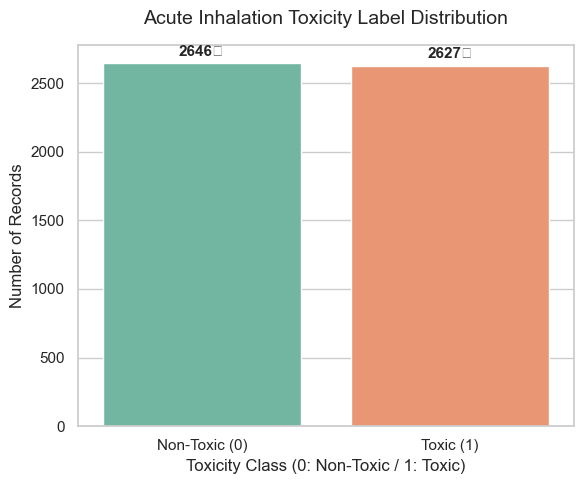

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))

# 라벨 카운트 시각화
ax = sns.countplot(x='Label', data=df_final, palette='Set2')

# 차트 제목 및 라벨 설정
plt.title('Acute Inhalation Toxicity Label Distribution', fontsize=14, pad=15)
plt.xlabel('Toxicity Class (0: Non-Toxic / 1: Toxic)', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks([0, 1], ['Non-Toxic (0)', 'Toxic (1)'])

# 바 위에 정확한 숫자 표시하기
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}개', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [45]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys

X_morgan = []
X_maccs = []
y_labels = []
valid_smiles = []

print("🧬 분자 Descriptor(Morgan Fingerprint & MACCS Keys) 계산 시작...")

smiles_col = 'Structure: SMILES' if 'Structure: SMILES' in df_final.columns else 'SMILES'

for idx, row in df_final.iterrows():
    smiles = row[smiles_col]
    label = row['Label']
    
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:  # 올바른 구조식인 경우에만 추출
        # 1. Morgan Fingerprint (Radius=2, 2048 bits)
        fp_morgan = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        X_morgan.append(np.array(fp_morgan))
        
        # 2. MACCS Keys (166 bits) -> 다양성 가산점 포인트!
        fp_maccs = MACCSkeys.GenMACCSKeys(mol)
        X_maccs.append(np.array(fp_maccs))
        
        y_labels.append(label)
        valid_smiles.append(smiles)

# 넘파이 배열로 변환
X_morgan = np.array(X_morgan)
X_maccs = np.array(X_maccs)
y = np.array(y_labels)

# 두 Descriptor를 하나로 합쳐서 풍부한 Feature 세트 구성 (선택 사항)
X_combined = np.hstack((X_morgan, X_maccs))

print("-" * 60)
print(f"🎉 Descriptor 계산 완료!")
print(f"   - Morgan Fingerprint 형태: {X_morgan.shape}")
print(f"   - MACCS Keys 형태: {X_maccs.shape}")
# 가산점을 위해 결합된 데이터셋 형태로 최종 출력 준비
print(f"   - 최종 결합된 Feature(X) 형태: {X_combined.shape}")
print(f"   - 최종 라벨(y) 형태: {y.shape}")
print("=" * 60)

🧬 분자 Descriptor(Morgan Fingerprint & MACCS Keys) 계산 시작...
------------------------------------------------------------
🎉 Descriptor 계산 완료!
   - Morgan Fingerprint 형태: (5231, 2048)
   - MACCS Keys 형태: (5231, 167)
   - 최종 결합된 Feature(X) 형태: (5231, 2215)
   - 최종 라벨(y) 형태: (5231,)


In [46]:
from sklearn.model_selection import train_test_split

# combined feature(X_combined)와 정답(y)을 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # 독성/비독성 비율을 균등하게 유지
)

print("=" * 60)
print("✂️ 데이터 분할 완료")
print(f"   - 학습용 데이터 (X_train): {X_train.shape}개")
print(f"   - 검증용 데이터 (X_test): {X_test.shape}개")
print(f"   - 학습용 라벨 비율: 0이 {list(y_train).count(0)}개 / 1이 {list(y_train).count(1)}개")
print("=" * 60)

✂️ 데이터 분할 완료
   - 학습용 데이터 (X_train): (4184, 2215)개
   - 검증용 데이터 (X_test): (1047, 2215)개
   - 학습용 라벨 비율: 0이 2116개 / 1이 2068개


In [47]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import pandas as pd

# 1. 모델 정의
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)
}

# 2. 성능 지표를 담을 리스트
results = []

print("🚀 머신러닝 모델 학습 및 평가 시작...")

for name, model in models.items():
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측값 및 예측 확률 추출
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # 평가지표 계산
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "AUC Score": auc
    })

# 3. 결과를 깔끔한 데이터프레임으로 변환 및 출력
df_perf = pd.DataFrame(results)
print("\n" + "=" * 60)
print("📊 최종 모델 성능 비교 결과표")
print("=" * 60)
display(df_perf.round(4))
print("=" * 60)

🚀 머신러닝 모델 학습 및 평가 시작...

📊 최종 모델 성능 비교 결과표


,Model,Accuracy,Precision,Recall,AUC Score
0,Random Forest,0.7135,0.7472,0.6344,0.7751
1,XGBoost,0.7058,0.7370,0.6286,0.7643
